## Credit Card Clustering ##
This project segments credit card customers into distinct groups based on their spending and payment behavior, using unsupervised learning (K-Means clustering). Since there are no predefined labels, the goal is to discover natural groupings in the data and interpret what makes each group different.

## Steps ##
1. Load the data and perform exploratory data analysis (EDA)
2. Handle missing values and drop non-informative columns
3. Scale the features with `StandardScaler`, since K-Means is distance-based
4. Choose the number of clusters using the Elbow method and Silhouette score
5. Train the K-Means model and profile each cluster
6. Visualize the clusters in 2D using PCA
7. Create a streamlit app

In [1]:
# LOAD THE DATA
import pandas as pd
url = "https://raw.githubusercontent.com/Jhoie/Credit-Card-Analysis-Kaggle-/master/CC%20GENERAL.csv"
df = pd.read_csv(url)
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
df.tail()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.50,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.00,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.25,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.25,6
8949,C19190,372.708075,0.666667,1093.25,1093.25,0.00,127.040008,0.666667,0.666667,0.000000,0.333333,2,23,1200.0,63.165404,88.288956,0.00,6


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [5]:
# EDA
df.isnull().sum()



,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [6]:
df = df.dropna(subset=['CREDIT_LIMIT'])

In [7]:
eksik = df[df['MINIMUM_PAYMENTS'].isnull()]
dolu = df[df['MINIMUM_PAYMENTS'].notnull()]

cols = ['BALANCE', 'PURCHASES', 'PAYMENTS', 'PURCHASES_FREQUENCY']
pd.DataFrame({'eksik': eksik[cols].mean(), 'dolu': dolu[cols].mean()})

,eksik,dolu
BALANCE,555.441321,1601.224893
PURCHASES,393.087284,1025.433874
PAYMENTS,322.286168,1784.478099
PURCHASES_FREQUENCY,0.336043,0.496000


In [8]:
print((eksik['PAYMENTS'] == 0).mean())
print((eksik['BALANCE'] == 0).mean())
print((eksik['PURCHASES'] == 0).mean())

0.7667731629392971
0.2364217252396166
0.24281150159744408


In [10]:
# Eksiklerin çoğunluğu karta kullanmayanlar, bunlara "0" değerini verelim.
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(0)
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [11]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000,8949.000000
mean,1564.647593,0.877350,1003.316936,592.503572,411.113579,978.959616,0.490405,0.202480,0.364478,0.135141,3.249078,14.711476,4494.449450,1733.336511,834.075035,0.153732,11.517935
std,2081.584016,0.236798,2136.727848,1659.968851,904.378205,2097.264344,0.401360,0.298345,0.397451,0.200132,6.824987,24.858552,3638.815725,2895.168146,2336.104378,0.292511,1.337134
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.000000,0.000000,6.000000
25%,128.365782,0.888889,39.800000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.282850,163.029483,0.000000,12.000000
50%,873.680279,1.000000,361.490000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,857.062706,289.686899,0.000000,12.000000
75%,2054.372848,1.000000,1110.170000,577.830000,468.650000,1113.868654,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.279320,788.721609,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


array([[<Axes: title={'center': 'BALANCE'}>,
        <Axes: title={'center': 'BALANCE_FREQUENCY'}>,
        <Axes: title={'center': 'PURCHASES'}>,
        <Axes: title={'center': 'ONEOFF_PURCHASES'}>],
       [<Axes: title={'center': 'INSTALLMENTS_PURCHASES'}>,
        <Axes: title={'center': 'CASH_ADVANCE'}>,
        <Axes: title={'center': 'PURCHASES_FREQUENCY'}>,
        <Axes: title={'center': 'ONEOFF_PURCHASES_FREQUENCY'}>],
       [<Axes: title={'center': 'PURCHASES_INSTALLMENTS_FREQUENCY'}>,
        <Axes: title={'center': 'CASH_ADVANCE_FREQUENCY'}>,
        <Axes: title={'center': 'CASH_ADVANCE_TRX'}>,
        <Axes: title={'center': 'PURCHASES_TRX'}>],
       [<Axes: title={'center': 'CREDIT_LIMIT'}>,
        <Axes: title={'center': 'PAYMENTS'}>,
        <Axes: title={'center': 'MINIMUM_PAYMENTS'}>,
        <Axes: title={'center': 'PRC_FULL_PAYMENT'}>],
       [<Axes: title={'center': 'TENURE'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

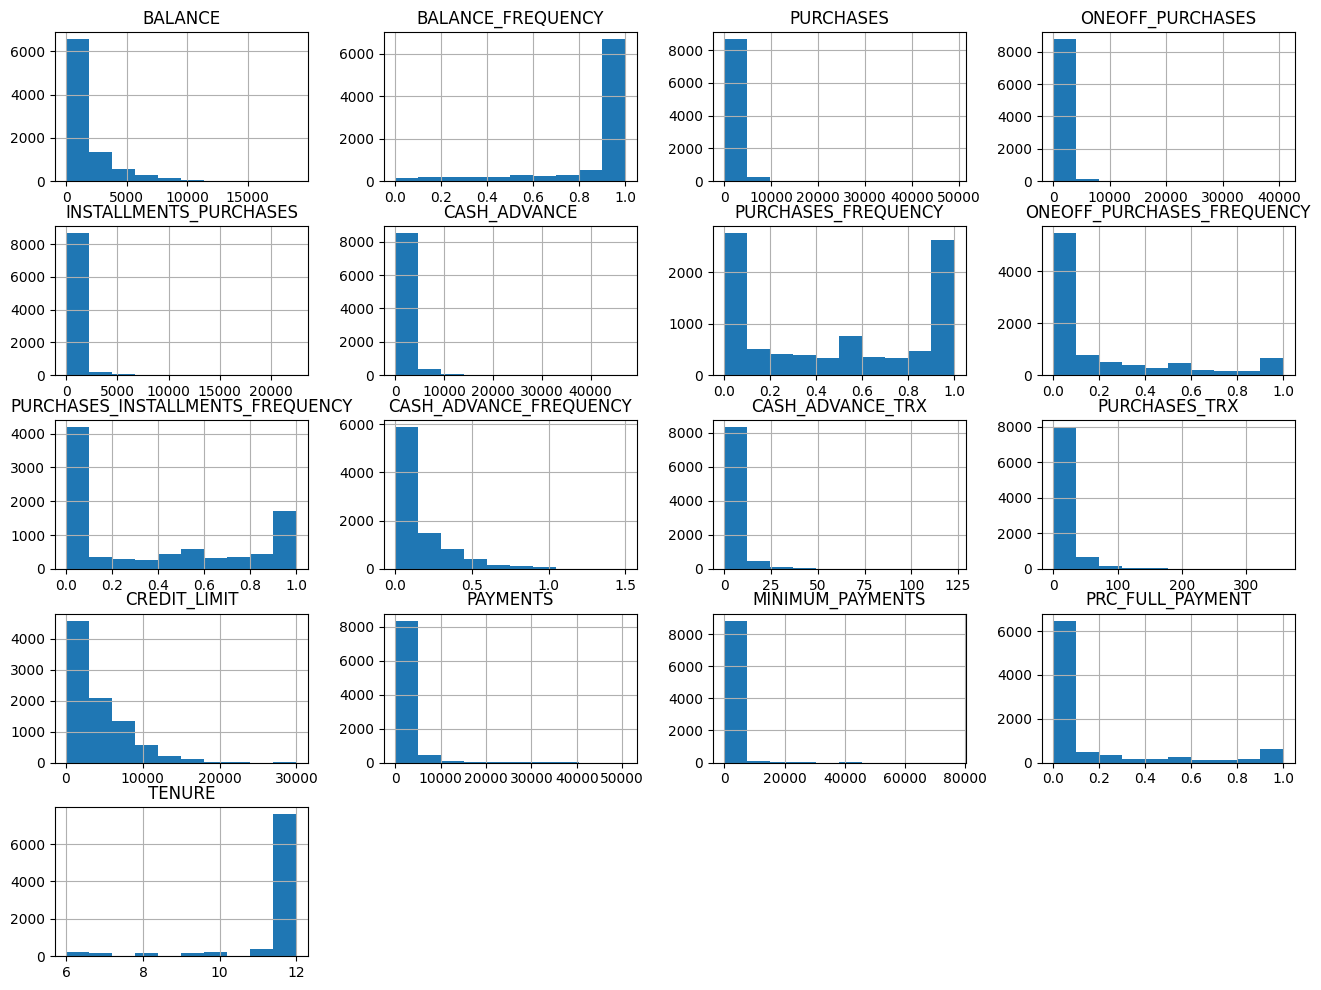

In [12]:
df.hist(figsize=(16,12))

In [13]:
# SCALER
from sklearn.preprocessing import StandardScaler

x = df.drop(columns='CUST_ID')
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [15]:
# K-Means
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(x_scaled)

df['cluster'] = kmeans.labels_
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,3
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,1
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,0.000000,0.000000,12,3
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,3


In [16]:
df['cluster'].value_counts()
df.drop(columns='CUST_ID').groupby('cluster').mean().round(1)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
cluster,,,,,,,,,,,,,,,,,
0,3551.2,1.0,7681.6,5095.9,2587.2,653.6,0.9,0.7,0.8,0.1,2.1,89.4,9696.9,7288.7,1970.5,0.3,12.0
1,894.8,0.9,1236.3,594.0,642.5,209.8,0.9,0.3,0.7,0.0,0.8,22.1,4214.0,1331.3,633.8,0.3,11.6
2,4602.4,1.0,501.9,320.2,181.8,4521.5,0.3,0.1,0.2,0.5,14.3,7.7,7546.2,3484.1,2000.5,0.0,11.4
3,1013.0,0.8,270.3,210.1,60.5,597.2,0.2,0.1,0.1,0.1,2.1,2.9,3278.3,975.3,535.6,0.1,11.4


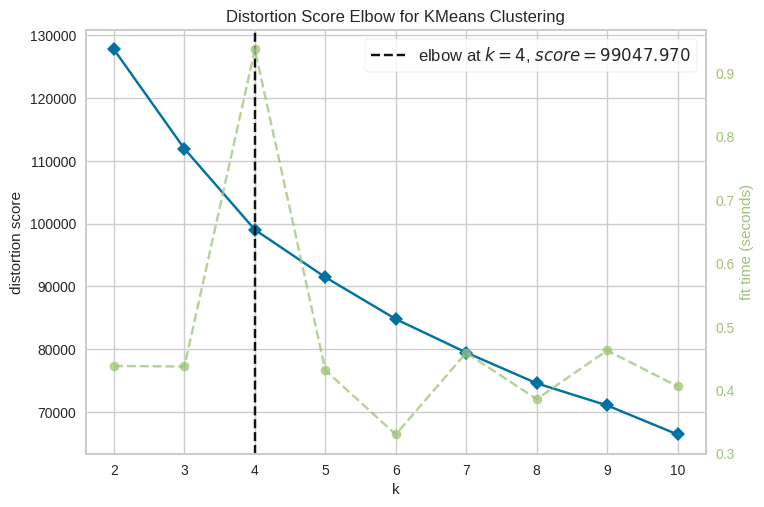

4


In [17]:
# Elbow Model
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

model = KMeans(random_state=42, n_init=10)
visualizer = KElbowVisualizer(model, k=(2, 11))

visualizer.fit(x_scaled)
visualizer.show()

print(visualizer.elbow_value_)


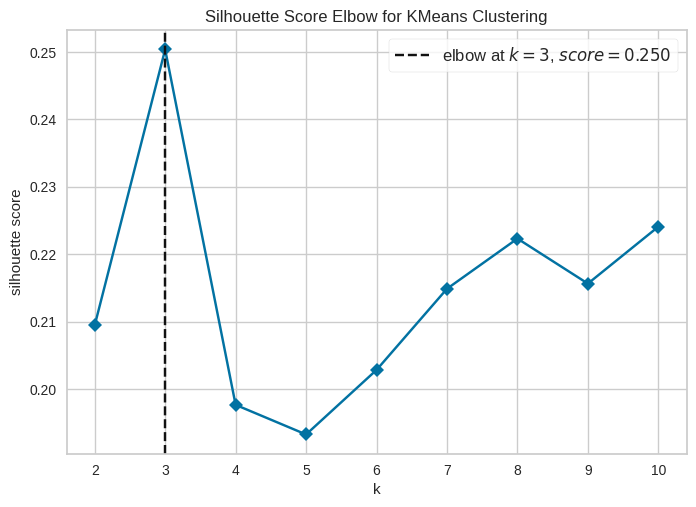

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [18]:
visualizer = KElbowVisualizer(KMeans(random_state=42, n_init=10), k=(2, 11), metric='silhouette', timings=False)
visualizer.fit(x_scaled)
visualizer.show()

In [19]:
import pandas as pd
from sklearn.cluster import KMeans

pd.set_option('display.max_columns', 100)

labels_3 = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(x_scaled)
labels_4 = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(x_scaled)

print('--- k=3 ---')
print(pd.Series(labels_3).value_counts().sort_index())
print(x.groupby(labels_3).mean().round(1).T)

print('--- k=4 ---')
print(pd.Series(labels_4).value_counts().sort_index())
print(x.groupby(labels_4).mean().round(1).T)

--- k=3 ---
0    1237
1    6118
2    1594
Name: count, dtype: int64
                                       0       1       2
BALANCE                           2230.3   799.9  3983.4
BALANCE_FREQUENCY                    1.0     0.8     1.0
PURCHASES                         4264.9   505.6   382.5
ONEOFF_PURCHASES                  2714.3   253.2   248.4
INSTALLMENTS_PURCHASES            1551.1   252.8   134.2
CASH_ADVANCE                       460.9   330.8  3868.6
PURCHASES_FREQUENCY                  0.9     0.5     0.2
ONEOFF_PURCHASES_FREQUENCY           0.7     0.1     0.1
PURCHASES_INSTALLMENTS_FREQUENCY     0.7     0.3     0.1
CASH_ADVANCE_FREQUENCY               0.1     0.1     0.4
CASH_ADVANCE_TRX                     1.5     1.2    12.4
PURCHASES_TRX                       56.5     8.7     5.5
CREDIT_LIMIT                      7735.6  3271.6  6672.8
PAYMENTS                          4150.7   909.8  3018.2
MINIMUM_PAYMENTS                  1244.7   508.9  1763.5
PRC_FULL_PAYMENT    

In [20]:
# Decision k=4 is better

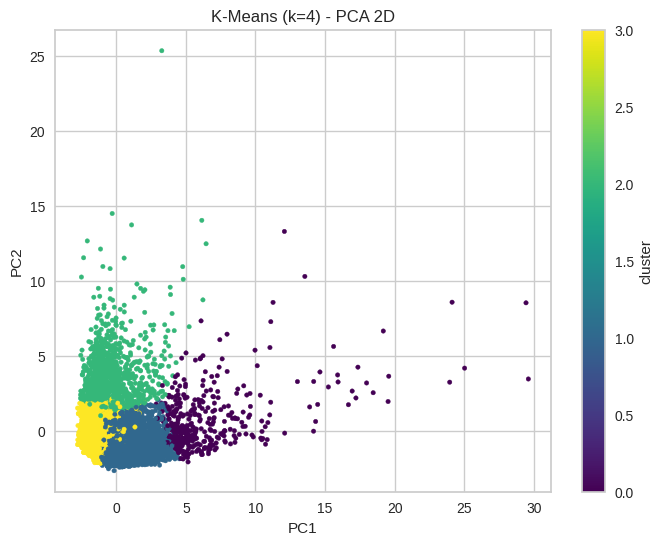

In [22]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10).fit(x_scaled)
df['cluster'] = kmeans.labels_

x_pca = PCA(n_components=2, random_state=42).fit_transform(x_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=df['cluster'], s=10, cmap='viridis')
plt.title('K-Means (k=4) - PCA 2D')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='cluster')
plt.show()

In [24]:
# Cluster Summary (K-Means, k = 4)
# We chose k = 4 using the Elbow method.
# Cluster 0:   409 - Premium Spenders - Spend the most, have the highest credit limits, and make many purchases.
# Cluster 1: 3.366 - Frequent Small Shoppers - Buy often, but in small amounts, mostly with installments.
# Cluster 2: 1.197 - Cash Advance Users - Take a lot of cash advances, buy little, and rarely pay in full.
# Cluster 3: 3.977 - Inactive Customers - Rarely use the card and have low balances and limits.

In [25]:
# BEFORE STREAMLIT
import pickle
from sklearn.pipeline import make_pipeline

cluster_pipe = make_pipeline(
    StandardScaler(),
    KMeans(n_clusters=4, random_state=42, n_init=10)
)
cluster_pipe.fit(x)

print((cluster_pipe.predict(x) == df['cluster']).all())

pickle.dump(cluster_pipe, open(r"cluster_model.pkl", "wb"))

True
